# Initial-condition Fisher information from the PSMAP

This notebook calculates how precisely a **complete state-resolved 2D image** can determine the eight Gaussian initial-cloud parameters

$$\theta=(\mu_{x0},\mu_{y0},\mu_{v_x0},\mu_{v_y0},\sigma_{x0},\sigma_{y0},\sigma_{v_x0},\sigma_{v_y0}).$$

Unlike the synthetic-shot pipeline, this calculation does not sample atoms. It deterministically integrates the single-atom PSMAP response against a Gaussian initial distribution. The resulting Cramer-Rao lower bound is an information-theoretic benchmark: no unbiased estimator using the same image can beat it.

## Model and analytic derivatives

At every PSMAP node $q=(x_0,y_0,v_{x0},v_{y0})$, ais++ supplies output-port amplitudes and phases. These define state probabilities $P_s(q,\phi_0)$. For Gaussian cloud parameters $\theta$, the expected probability in state $s$ and final-position bin $b$ is

$$p_{s,b}(\theta)=\int dq\;p(q\mid\theta)P_s(q,\phi_0)\,\mathbf{1}[x_f(q),y_f(q)\in b].$$

At each final-image location, the marginal Gaussian density is analytic and the initial velocities conditioned on that final position remain Gaussian. The remaining two-dimensional conditional integral is evaluated deterministically with Gauss-Hermite quadrature and linear interpolation of the PSMAP response. The derivative identity is

$$\partial_{\theta_j}p_{s,b}=\mathbb{E}_{q\sim p(q|\theta)}\!\left[P_s(q,\phi_0)\mathbf{1}_b\,\partial_{\theta_j}\log p(q|\theta)\right].$$

The notebook evaluates derivatives with stable central differences of the smooth deterministic image probabilities. For $N$ launched atoms, the multinomial Fisher matrix is

$$F_{ij}=N\sum_k\frac{1}{p_k}\frac{\partial p_k}{\partial\theta_i}\frac{\partial p_k}{\partial\theta_j},$$

where $k$ runs over all ground/excited image bins and the undetected category. The covariance bound is $F^{-1}$ when all parameter combinations are identifiable.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))

from aispy.psmap import load_psmap
from helpers.psmap_fisher import PARAMETER_NAMES, PSMAPConditionalImageModel


## Configuration

`T_DET` must match the value supplied to `PSMAPSurrogate` when generating the dataset. The nominal cloud below matches the current synthetic-data configuration. `PARAMETER_SCALES` only improves numerical conditioning; it does not impose a prior.

In [ ]:
PSMAP_PATH = REPO / 'output-files' / 'PSGRID4D_CONFOCAL_Z0.h5'
T_DET = 3.8
PHI0 = 0.
N_ATOMS = 10_000_000
HERMITE_ORDER = 12  # increase to 16 to check quadrature convergence

# Match the compact 2D-image artifacts: 64 bins over +/-5 mm.
N_BINS = 64
IMAGE_RANGE = 3e-3
x_edges = np.linspace(-IMAGE_RANGE, IMAGE_RANGE, N_BINS + 1)
y_edges = np.linspace(-IMAGE_RANGE, IMAGE_RANGE, N_BINS + 1)

# Order: mu_x0, mu_y0, mu_vx0, mu_vy0, sigma_x0, sigma_y0, sigma_vx0, sigma_vy0.
theta_nominal = np.array([0, 0, 0, 0, 100e-6, 100e-6, 309e-6/3, 309e-6/3], dtype=float)

# Typical shot-to-shot variation scales used only to condition the Fisher matrix.
parameter_scales = np.array([10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6])
derivative_steps = parameter_scales * 1e-2

print(f'PSMAP: {PSMAP_PATH}')
print(f'Known phase: phi0 = {PHI0:.3f} rad; launched atoms = {N_ATOMS:,}')


PSMAP: /home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/output-files/PSGRID4D_CONFOCAL_Z0.h5
Known phase: phi0 = 0.000 rad; launched atoms = 1,000,000


## Build the deterministic image model

This interpolates the PSMAP response and integrates the conditional initial-velocity distribution at every final-image location using Gauss-Hermite quadrature.

In [18]:
psmap = load_psmap(PSMAP_PATH)
model = PSMAPConditionalImageModel.from_psmap(
    psmap, T_DET, PHI0, x_edges, y_edges, hermite_order=HERMITE_ORDER
)

probabilities, jacobian, detected_probability = model.probabilities_and_jacobian(
    theta_nominal, derivative_steps, observation_model="launched"
)
print(f"Gauss-Hermite order per velocity axis: {HERMITE_ORDER}")
print(f"Probability detected inside image ROI: {detected_probability:.6f}")
print(f"Probability normalization check: {probabilities.sum():.12f}")
print(f"Max derivative-sum error: {np.abs(jacobian.sum(axis=0)).max():.3e}")


Gauss-Hermite order per velocity axis: 12
Probability detected inside image ROI: 0.896176
Probability normalization check: 1.000000000000
Max derivative-sum error: 0.000e+00


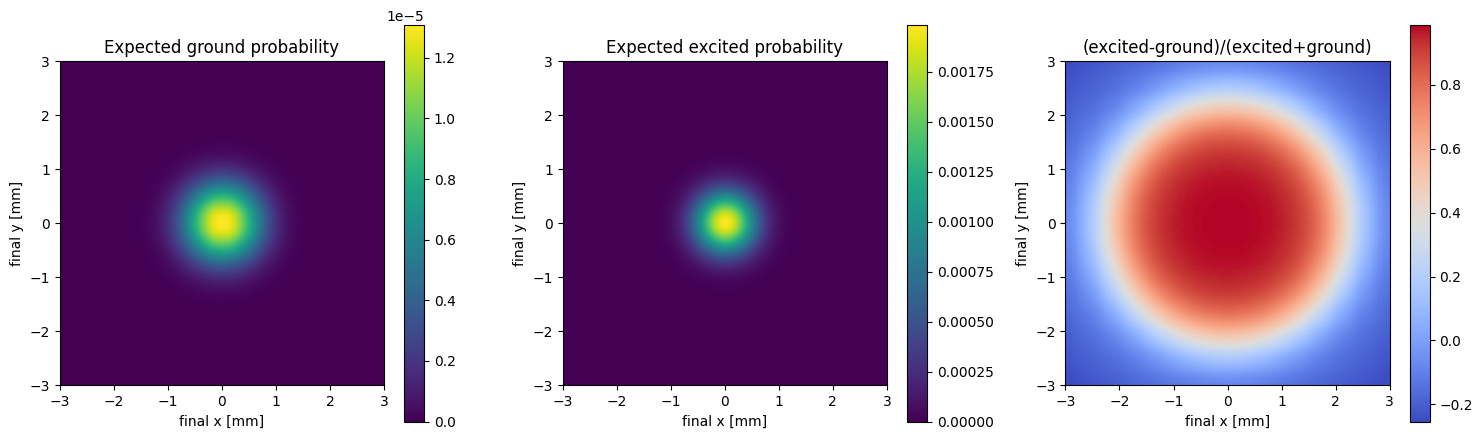

In [19]:
n_pixels = N_BINS * N_BINS
ground_image = probabilities[:n_pixels].reshape(N_BINS, N_BINS)
excited_image = probabilities[n_pixels:2*n_pixels].reshape(N_BINS, N_BINS)
extent = np.array([-IMAGE_RANGE, IMAGE_RANGE, -IMAGE_RANGE, IMAGE_RANGE]) * 1e3

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, image, title in zip(
    axs[:2], [ground_image, excited_image], ['Expected ground probability', 'Expected excited probability']
):
    im = ax.imshow(image.T, origin='lower', extent=extent, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('final x [mm]')
    ax.set_ylabel('final y [mm]')
    fig.colorbar(im, ax=ax)

contrast = np.divide(excited_image - ground_image, excited_image + ground_image,
                     out=np.zeros_like(ground_image), where=(excited_image + ground_image) > 0)
im = axs[2].imshow(contrast.T, origin='lower', extent=extent, cmap='coolwarm', aspect='equal',)# vmin=-1, vmax=1)
axs[2].set_title('(excited-ground)/(excited+ground)')
axs[2].set_xlabel('final x [mm]')
axs[2].set_ylabel('final y [mm]')
fig.colorbar(im, ax=axs[2])
fig.tight_layout()


## Full-image Fisher information and precision bound

The `launched` model uses the state-resolved image plus the number of undetected/out-of-ROI atoms, assuming the launched atom count is known. The `detected_conditional` model fixes the detected count and discards all information carried by detection efficiency. The latter is the more conservative comparison when only normalized detected images are used.

In [20]:
launched_result = model.fisher_information(
    theta_nominal, N_ATOMS, parameter_scales, observation_model='launched'
)
conditional_result = model.fisher_information(
    theta_nominal, N_ATOMS * detected_probability, parameter_scales,
    observation_model='detected_conditional'
)

display_scales = np.array([1e6, 1e6, 1e6, 1e6, 1e6, 1e6, 1e6, 1e6])
units = ['um', 'um', 'um/s', 'um/s', 'um', 'um', 'um/s', 'um/s']
precision_table = pd.DataFrame({
    'parameter': PARAMETER_NAMES,
    'unit': units,
    'nominal_value': theta_nominal * display_scales,
    'CRLB_known_launched_count': launched_result.standard_deviations * display_scales,
    'CRLB_detected_images_only': conditional_result.standard_deviations * display_scales,
}).set_index('parameter')
display(precision_table)

print(f'Known-launched-count rank: {launched_result.rank}/8; condition number: {launched_result.condition_number:.3e}')
print(f'Detected-image-only rank: {conditional_result.rank}/8; condition number: {conditional_result.condition_number:.3e}')
print('All bounds scale as 1/sqrt(N) for otherwise fixed settings.')


,unit,nominal_value,CRLB_known_launched_count,CRLB_detected_images_only
parameter,,,,
mu_x0,um,0.0,47.833562,47.833562
mu_y0,um,0.0,47.833562,47.833562
mu_vx0,um/s,0.0,12.462683,12.462683
mu_vy0,um/s,0.0,12.462683,12.462683
sigma_x0,um,100.0,36.975713,46.760852
sigma_y0,um,100.0,36.975713,46.760852
sigma_vx0,um/s,103.0,2.414177,3.045499
sigma_vy0,um/s,103.0,2.414177,3.045499


Known-launched-count rank: 8/8; condition number: 3.668e+05
Detected-image-only rank: 8/8; condition number: 3.604e+05
All bounds scale as 1/sqrt(N) for otherwise fixed settings.


## Optional numerical convergence check

Before quoting final precision values, compare several Gauss-Hermite orders. Stable values indicate that the conditional-velocity integral is resolved; residual variation provides a practical numerical uncertainty estimate.

In [7]:
RUN_QUADRATURE_CHECK = False

if RUN_QUADRATURE_CHECK:
    convergence_rows = []
    for order in (8, 12, 16):
        check_model = PSMAPConditionalImageModel.from_psmap(
            psmap, T_DET, PHI0, x_edges, y_edges, hermite_order=order
        )
        check_result = check_model.fisher_information(
            theta_nominal, N_ATOMS, parameter_scales, derivative_steps=derivative_steps
        )
        convergence_rows.append({
            "Hermite order": order,
            **{name: value * display_scales[index]
               for index, (name, value) in enumerate(zip(PARAMETER_NAMES, check_result.standard_deviations))},
        })
    display(pd.DataFrame(convergence_rows).set_index("Hermite order"))
else:
    print("Set RUN_QUADRATURE_CHECK=True before quoting final bounds.")


Set RUN_QUADRATURE_CHECK=True before quoting final bounds.


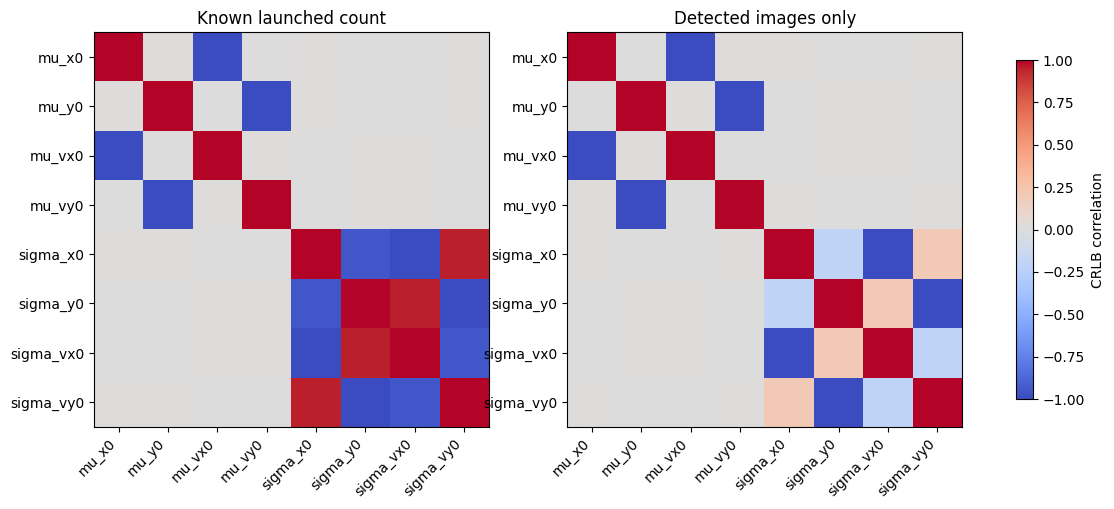

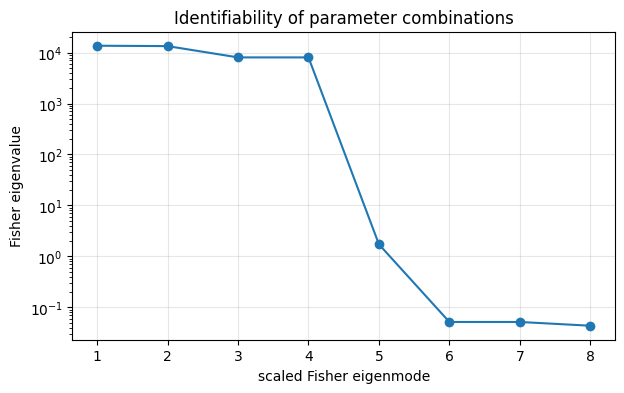

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, result, title in zip(
    axs,
    [launched_result, conditional_result],
    ['Known launched count', 'Detected images only'],
):
    im = ax.imshow(result.correlation, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(8), PARAMETER_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(8), PARAMETER_NAMES)
    ax.set_title(title)
fig.colorbar(im, ax=axs, label='CRLB correlation', shrink=0.8)

plt.figure(figsize=(7, 4))
eigenvalues = launched_result.eigenvalues_scaled[::-1]
plt.semilogy(range(1, 9), np.maximum(eigenvalues, 1e-300), marker='o')
plt.xlabel('scaled Fisher eigenmode')
plt.ylabel('Fisher eigenvalue')
plt.title('Identifiability of parameter combinations')
plt.grid(alpha=0.3)


## Optional: dependence on interferometer phase

A single-shot image can carry very different information at fringe maximum and mid-fringe. Enable this scan to see whether the selected or randomly sampled $\phi_0$ values leave particular initial conditions poorly constrained.

In [9]:
RUN_PHASE_SCAN = False

if RUN_PHASE_SCAN:
    phase_values = np.linspace(0, 2*np.pi, 13, endpoint=False)
    phase_precisions = []
    for phase in phase_values:
        phase_model = PSMAPConditionalImageModel.from_psmap(
            psmap, T_DET, phase, x_edges, y_edges, hermite_order=HERMITE_ORDER
        )
        result = phase_model.fisher_information(theta_nominal, N_ATOMS, parameter_scales)
        phase_precisions.append(result.standard_deviations * display_scales)
    phase_precisions = np.asarray(phase_precisions)

    fig, axs = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
    for index, ax in enumerate(axs.flat):
        ax.plot(phase_values, phase_precisions[:, index], marker='o')
        ax.set_title(PARAMETER_NAMES[index])
        ax.set_ylabel(f'CRLB [{units[index]}]')
        ax.set_xlabel('phi0 [rad]')
        ax.grid(alpha=0.3)
    fig.tight_layout()
else:
    print('Set RUN_PHASE_SCAN=True to calculate phase-dependent bounds.')


Set RUN_PHASE_SCAN=True to calculate phase-dependent bounds.


## Optional comparison with PCA/summary-feature regression

This cell trains the existing quadratic Ridge feature model and evaluates it on complete held-out runs. The resulting RMSE is directly comparable in units, but not identical in interpretation, to the nominal-shot Fisher bound: the dataset spans many cloud parameters and phases, whereas the Fisher bound is local at `theta_nominal` and `PHI0`. A large RMSE/CRLB ratio indicates information lost by feature compression, estimator choice, or training limitations.

A feature-regression RMSE below the CRLB is not a violation: the regression is generally biased and learns the finite parameter distribution in the training set, whereas this CRLB is a local bound for unbiased estimation of one nominal cloud from binned images. The feature model also uses separately calculated final-position moments.


In [10]:
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

artifact_dir = REPO / 'results' / '2d-shot-features'
pca_path = artifact_dir / '2d-shot-pcas.npz'

if (artifact_dir / 'shot_metadata.npz').exists() and pca_path.exists():
    metadata = np.load(artifact_dir / 'shot_metadata.npz')
    pca = np.load(pca_path)
    X = np.column_stack([metadata['summary_features'], pca['scores'][:, :5]])
    targets = {name: metadata[name if not name.startswith('sigma_') else name.replace('0', '')] for name in PARAMETER_NAMES}
    train, test = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, groups=metadata['run_id']))
    feature_model = Pipeline([
        ('input_scaler', StandardScaler()),
        ('quadratic_features', PolynomialFeatures(2, include_bias=False)),
        ('quadratic_scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1e-2)),
    ])
    rows = []
    for index, (name, target) in enumerate(targets.items()):
        prediction = clone(feature_model).fit(X[train], target[train]).predict(X[test])
        rmse = np.sqrt(mean_squared_error(target[test], prediction))
        fisher_std = conditional_result.standard_deviations[index]
        rows.append({'parameter': name, 'held_out_feature_RMSE': rmse * display_scales[index],
                     'nominal_full_image_CRLB': fisher_std * display_scales[index],
                     'RMSE_over_CRLB': rmse / fisher_std, 'unit': units[index]})
    display(pd.DataFrame(rows).set_index('parameter'))
else:
    print(f'Feature artifacts not found at {artifact_dir}; run the extraction/PCA pipeline first.')


,held_out_feature_RMSE,nominal_full_image_CRLB,RMSE_over_CRLB,unit
parameter,,,,
mu_x0,10.161041,42.598571,0.238530,um
mu_y0,9.372287,42.598571,0.220014,um
mu_vx0,2.253079,11.097902,0.203018,um/s
mu_vy0,2.044561,11.097902,0.184229,um/s
sigma_x0,10.321500,43.573552,0.236875,um
sigma_y0,9.897676,43.573552,0.227149,um
sigma_vx0,0.548183,2.834341,0.193407,um/s
sigma_vy0,0.544113,2.834341,0.191971,um/s


## Interpretation checklist

- A rank below eight means at least one combination of initial conditions is not locally identifiable from this measurement.
- Very large CRLB correlations expose degeneracies, such as final position constraining a combination of initial position and velocity.
- The full-image CRLB is the correct upper benchmark for PCA, phase-gradient, curvature, or moment-based estimators.
- Compare Gauss-Hermite orders (for example 8, 12, and 16) before quoting final numbers; the residual variation is numerical integration uncertainty.
- This benchmark assumes the PSMAP, phase, atom number model, and imaging response are known exactly. Experimental nuisance parameters would weaken the bound and should eventually be added to $\theta$.